# Bab 3 — Statistical Experiments and Significance Testing
**Practical Statistics for Data Scientists, 2nd Edition** — Peter Bruce, Andrew Bruce & Peter Gedeck (O'Reilly, 2020)

1. A/B testing
2. Uji hipotesis (null & alternative hypothesis, one-way vs two-way)
3. Resampling & permutation test
4. Signifikansi statistik dan p-value (alpha, error tipe I & II)
5. t-test
6. Multiple testing
7. Degrees of freedom
8. ANOVA
9. Chi-square test (termasuk Fisher's exact test)
10. Multi-arm bandit
11. Power dan ukuran sampel


In [1]:
!pip install statsmodels

In [2]:
%matplotlib inline
import random
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats import power
import matplotlib.pyplot as plt

DATA = 'https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/'

## Gambaran Besar: Inferensi Statistik

Desain eksperimen adalah fondasi statistik. Alurnya kira-kira:

**Rumuskan hipotesis → Rancang eksperimen → Kumpulkan data → Lakukan inferensi/ambil kesimpulan**

Istilah **inferensi** berarti menerapkan hasil eksperimen yang dilakukan pada sekelompok kecil subjek ke populasi yang lebih besar. Tujuannya: memastikan pola yang kita lihat bukan sekadar kebetulan acak.

## 1. A/B Testing

**A/B test** = eksperimen dengan dua kelompok untuk menentukan mana dari dua perlakuan, produk, atau prosedur yang lebih baik. Salah satunya biasanya perlakuan standar (**kontrol**), atau bisa juga tanpa perlakuan sama sekali.

**Istilah kunci:**
- **Treatment** — sesuatu yang diberikan ke subjek (obat, harga, judul halaman web).
- **Treatment group** — kelompok yang mendapat perlakuan tertentu.
- **Control group** — kelompok yang mendapat perlakuan standar atau tanpa perlakuan.
- **Randomization** — subjek dimasukkan ke kelompok secara acak.
- **Subjects** — unit yang diberi perlakuan (orang, pengunjung web, tanaman).
- **Test statistic** — metrik yang dipakai mengukur efek perlakuan.

**Contoh A/B test:**
- Dua jenis pengolahan tanah → mana yang membuat biji tumbuh lebih baik.
- Dua terapi → mana yang lebih efektif menekan kanker.
- Dua harga → mana yang memberi keuntungan bersih lebih besar.
- Dua judul berita/halaman web → mana yang menghasilkan lebih banyak klik.

**Kenapa perlu kelompok kontrol?** Tanpa kontrol, tidak ada jaminan bahwa "faktor lain" sama untuk semua kelompok, sehingga kita tidak tahu apakah perbedaannya disebabkan perlakuan atau hal lain.

**Metrik harus ditentukan sebelum eksperimen.** Kalau metrik dipilih setelah melihat hasil, kita membuka pintu untuk bias peneliti.

**Blinding:** *blind study* = subjek tidak tahu mendapat perlakuan A atau B. *Double-blind* = peneliti yang berinteraksi dengan subjek juga tidak tahu. Di A/B test web, subjek biasanya tidak sadar sedang dieksperimenkan, jadi blinding relatif mudah.

**Kenapa hanya A/B?** Dalam praktik, eksperimen sering melibatkan lebih dari dua varian dan bisa lebih efisien dengan pendekatan lain seperti **multi-arm bandit** (lihat bagian 10).

## 2. Uji Hipotesis (Significance Test)

Tujuan uji hipotesis: membantu kita tahu apakah efek yang terlihat **mungkin hanya kebetulan acak**.

**Istilah kunci:**
- **Null hypothesis ($H_0$)** — hipotesis bahwa yang terjadi hanyalah kebetulan (tidak ada efek/perbedaan).
- **Alternative hypothesis ($H_A$)** — lawan dari null (yang ingin kita buktikan).
- **One-way test** — uji yang hanya menghitung kebetulan ekstrem ke **satu arah**.
- **Two-way test** — uji yang menghitung kebetulan ekstrem ke **dua arah**.

**Kenapa perlu uji hipotesis?** Manusia cenderung **meremehkan peran keacakan**. Kita mudah melihat pola dalam urutan acak dan menafsirkan kejadian ekstrem sebagai sesuatu yang bermakna. Contoh dari buku: jika orang diminta menulis urutan 50 lemparan koin "karangan", hasilnya biasanya terlalu jarang punya deretan panjang H atau T berturut-turut, padahal urutan acak asli sering memilikinya.

**Logikanya:** Kita menganggap $H_0$ benar ("tidak ada perbedaan antara A dan B"), lalu bertanya: *seberapa mungkin perbedaan yang kita amati muncul hanya karena keacakan?* Kalau sangat tidak mungkin, kita menolak $H_0$.

**Alternative hypothesis** harus melengkapi null. Contoh pasangan:
- $H_0$: "rata-rata A dan B sama" ↔ $H_A$: "rata-rata A berbeda dari B"
- $H_0$: "A ≤ B" ↔ $H_A$: "B > A"

**One-way vs Two-way:**
- Dalam A/B test yang membandingkan opsi baru (B) dengan standar (A), kita sering hanya peduli apakah B **lebih baik**. Ini one-way (one-tail).
- Kalau kita ingin tahu apakah ada perbedaan ke arah mana pun, pakai two-way (two-tail). Ini lebih konservatif dan menjadi default di banyak software.
- Di data science, perbedaan ini biasanya tidak terlalu krusial karena presisi p-value jarang menjadi penentu utama.

In [3]:
# Ilustrasi: dalam 50 lemparan koin asli, berapa panjang deretan (run) terpanjang?
rng = np.random.default_rng(7)
def longest_run(x):
    best = cur = 1
    for a, b in zip(x[:-1], x[1:]):
        cur = cur + 1 if a == b else 1
        best = max(best, cur)
    return best

runs = [longest_run(rng.integers(0, 2, 50)) for _ in range(10_000)]
print('Rata-rata deretan terpanjang dari 50 lemparan:', np.mean(runs).round(2))
print('Peluang ada deretan >= 5 :', np.mean(np.array(runs) >= 5).round(3))

Rata-rata deretan terpanjang dari 50 lemparan: 5.97
Peluang ada deretan >= 5 : 0.824


Deretan 5 atau lebih "gambar"/"angka" berturut-turut ternyata **sangat umum** dalam 50 lemparan acak, sesuatu yang biasanya dianggap "tidak acak" oleh intuisi manusia.

## 3. Resampling dan Permutation Test

**Resampling** = mengambil sampel berulang dari data yang diamati untuk menilai variabilitas acak sebuah statistik. Ada dua jenis utama:
- **Bootstrap** (Bab 2) — untuk menilai keandalan sebuah estimasi.
- **Permutation test** — untuk menguji hipotesis, biasanya dengan dua kelompok atau lebih.

### Permutation Test
Disebut juga *randomization test*. Langkahnya:
1. **Gabungkan** hasil dari semua kelompok ke dalam satu kumpulan data.
2. **Acak**, lalu ambil sampel **tanpa pengembalian** sebesar kelompok A.
3. Dari sisa data, ambil sampel sebesar kelompok B (dan seterusnya untuk kelompok lain).
4. Hitung statistik yang sama seperti pada data asli (misalnya selisih mean).
5. Ulangi langkah 2–4 sebanyak $R$ kali untuk membentuk **distribusi permutasi**.

Lalu bandingkan statistik asli dengan distribusi permutasi:
- Jika perbedaan yang diamati berada **di dalam** sebaran permutasi → tidak ada bukti kuat; perbedaannya bisa karena kebetulan.
- Jika berada **di luar/ujung** sebaran → perbedaannya **signifikan secara statistik**.

### Contoh: Web Stickiness
Sebuah perusahaan ingin tahu halaman mana (A atau B) yang membuat pengunjung bertahan lebih lama (*session time*, dalam 100 detik). Durasi sesi dipakai sebagai proksi karena konversi penjualan terlalu jarang terjadi.

In [4]:
session_times = pd.read_csv(DATA + 'web_page_data.csv')
session_times.Time = 100 * session_times.Time   # konversi ke detik
print(session_times.groupby('Page')['Time'].describe().round(1))

        count   mean    std   min   25%    50%    75%    max
Page                                                        
Page A   21.0  126.3   88.5  21.0  67.0   95.0  173.0  342.0
Page B   15.0  162.0  101.1  43.0  80.0  147.0  234.5  357.0


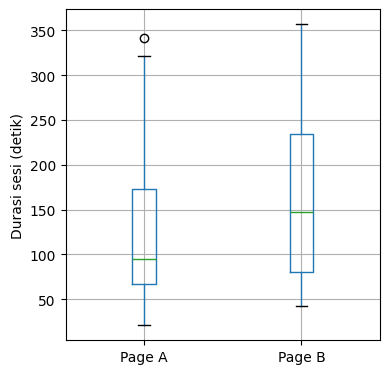

In [5]:
ax = session_times.boxplot(by='Page', column='Time', figsize=(4, 4))
ax.set_xlabel(''); ax.set_ylabel('Durasi sesi (detik)')
plt.suptitle(''); plt.title('')
plt.tight_layout(); plt.show()

In [6]:
mean_a = session_times[session_times.Page == 'Page A'].Time.mean()
mean_b = session_times[session_times.Page == 'Page B'].Time.mean()
print(f'Selisih mean (B - A): {mean_b - mean_a:.2f} detik')

Selisih mean (B - A): 35.67 detik


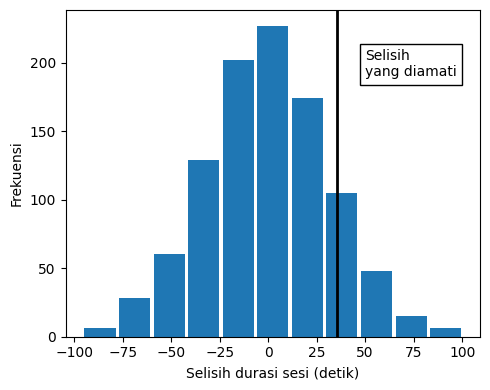

Proporsi permutasi >= selisih yang diamati: 0.121


In [7]:
# Fungsi permutasi
def perm_fun(x, nA, nB):
    n = nA + nB
    idx_B = set(random.sample(range(n), nB))
    idx_A = set(range(n)) - idx_B
    return x.loc[list(idx_B)].mean() - x.loc[list(idx_A)].mean()

nA = session_times[session_times.Page == 'Page A'].shape[0]
nB = session_times[session_times.Page == 'Page B'].shape[0]

random.seed(1)
perm_diffs = [perm_fun(session_times.Time, nA, nB) for _ in range(1000)]

fig, ax = plt.subplots(figsize=(5, 4))
ax.hist(perm_diffs, bins=11, rwidth=0.9)
ax.axvline(x=mean_b - mean_a, color='black', lw=2)
ax.text(50, 190, 'Selisih\nyang diamati', bbox={'facecolor': 'white'})
ax.set_xlabel('Selisih durasi sesi (detik)'); ax.set_ylabel('Frekuensi')
plt.tight_layout(); plt.show()

print('Proporsi permutasi >= selisih yang diamati:', np.mean(np.array(perm_diffs) > mean_b - mean_a))

Selisih yang diamati (~36 detik) berada **di dalam** sebaran permutasi. Sekitar 12–14% permutasi acak menghasilkan selisih sebesar itu atau lebih. Artinya, perbedaan durasi sesi antara halaman A dan B **tidak signifikan secara statistik**; bisa saja hanya karena kebetulan.

### Exhaustive dan Bootstrap Permutation Test
- **Exhaustive permutation test** — menghitung *semua* kemungkinan cara membagi data ke kelompok. Hanya praktis untuk data sangat kecil. Hasilnya pasti (*exact test*).
- **Bootstrap permutation test** — langkah 2 dan 3 dilakukan **dengan pengembalian**. Ini memodelkan tidak hanya keacakan pembagian ke kelompok, tapi juga keacakan dalam pemilihan subjek dari populasi.

### Nilai Permutation Test untuk Data Science
- Pendekatan **serbaguna**: bisa dipakai untuk data numerik maupun biner, ukuran sampel berbeda, tanpa asumsi distribusi normal.
- Tidak perlu menghafal rumus uji klasik. Cukup "acak, hitung, ulangi".

## 4. Signifikansi Statistik dan p-value

**Signifikansi statistik** adalah cara mengukur apakah hasil eksperimen (atau studi observasi) lebih ekstrem daripada yang bisa dihasilkan oleh kebetulan. Jika di luar batas variasi kebetulan, hasilnya disebut **signifikan secara statistik**.

**Istilah kunci:**
- **p-value** — peluang, di bawah model kebetulan ($H_0$), untuk mendapat hasil **seekstrem atau lebih ekstrem** dari hasil yang diamati.
- **Alpha ($\alpha$)** — ambang probabilitas "keanehan" yang harus dilampaui agar hasil dianggap signifikan (biasanya 5% atau 1%).
- **Type 1 error** — keliru menyimpulkan ada efek, padahal itu hanya kebetulan (*false positive*).
- **Type 2 error** — keliru menyimpulkan efek itu kebetulan, padahal efeknya nyata (*false negative*).

### Contoh dari buku: Tingkat Konversi E-commerce

| | Harga A | Harga B |
|---|---|---|
| Konversi | 200 | 182 |
| Tidak konversi | 23.539 | 22.406 |

Harga A konversinya sekitar 5% lebih tinggi (0,8425% vs 0,8057%, selisih 0,0368 poin persen). Apakah ini perbedaan nyata atau kebetulan?

Kita uji dengan permutation test: gabungkan semua 382 konversi dan 45.945 non-konversi (total 46.327 data, konversi keseluruhan 0,8246%), acak, bagi ulang menjadi kelompok berukuran 23.739 dan 22.588, lalu hitung selisih konversinya.

Selisih konversi yang diamati: 0.0368%


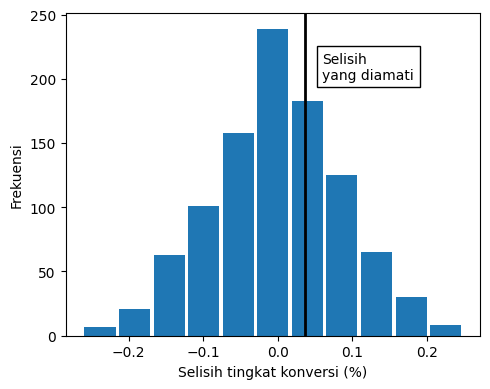

In [8]:
obs_pct_diff = 100 * (200 / 23739 - 182 / 22588)
print(f'Selisih konversi yang diamati: {obs_pct_diff:.4f}%')

conversion = [0] * 45945
conversion.extend([1] * 382)
conversion = pd.Series(conversion)

random.seed(1)
perm_diffs = [100 * perm_fun(conversion, 23739, 22588) for _ in range(1000)]

fig, ax = plt.subplots(figsize=(5, 4))
ax.hist(perm_diffs, bins=11, rwidth=0.9)
ax.axvline(x=obs_pct_diff, color='black', lw=2)
ax.text(0.06, 200, 'Selisih\nyang diamati', bbox={'facecolor': 'white'})
ax.set_xlabel('Selisih tingkat konversi (%)'); ax.set_ylabel('Frekuensi')
plt.tight_layout(); plt.show()

Selisih yang diamati (0,0368%) jelas berada **di tengah** variasi kebetulan.

### Menghitung p-value
**p-value dari permutasi** = proporsi permutasi yang menghasilkan selisih ≥ selisih yang diamati.

Bisa juga dihitung dengan pendekatan klasik: karena datanya binomial, kita bisa memakai aproksimasi normal (uji proporsi/chi-square) dengan `scipy.stats.chi2_contingency`.

In [9]:
print('p-value (permutasi):', np.mean([diff > obs_pct_diff for diff in perm_diffs]))

survivors = np.array([[200, 23739 - 200], [182, 22588 - 182]])
chi2, p_value, df, _ = stats.chi2_contingency(survivors)
print(f'p-value (one-sided, aproksimasi normal): {p_value / 2:.4f}')

p-value (permutasi): 0.332
p-value (one-sided, aproksimasi normal): 0.3498


Kedua pendekatan memberi p-value sekitar **0,3**. Artinya hasil seekstrem ini (atau lebih) diharapkan terjadi sekitar 30% waktu hanya karena kebetulan. Tidak signifikan.

### Alpha
Ambang $\alpha$ ditentukan **sebelum** eksperimen. Jika p-value < $\alpha$, hasil disebut signifikan. Nilai umum: 5% dan 1%. Pemilihannya sebagian besar konvensi, bukan hasil perhitungan objektif.

### Kontroversi p-value
p-value sering **disalahartikan**. Yang *ingin* diketahui peneliti: "Berapa peluang hasil ini karena kebetulan?" Yang *sebenarnya* dijawab p-value: "**Jika** model kebetulan benar, berapa peluang mendapat hasil seekstrem ini?"

Keduanya berbeda. Karena itu, p-value yang kecil **tidak** membuktikan bahwa hipotesis kita benar.

Pada 2016, **American Statistical Association (ASA)** menerbitkan pernyataan resmi yang merangkum prinsip-prinsip penting, antara lain:
1. p-value bisa menunjukkan seberapa tidak cocok data dengan model statistik tertentu.
2. p-value **tidak** mengukur probabilitas hipotesis benar, atau probabilitas data dihasilkan oleh kebetulan saja.
3. Kesimpulan ilmiah dan keputusan bisnis **tidak boleh hanya** bergantung pada apakah p-value melewati ambang tertentu.
4. Inferensi yang benar memerlukan pelaporan lengkap dan transparan.
5. p-value atau signifikansi statistik tidak mengukur **besarnya efek** atau **pentingnya** hasil.
6. p-value sendirian tidak memberi ukuran bukti yang baik mengenai sebuah model atau hipotesis.

### Practical Significance
Hasil yang signifikan secara statistik **belum tentu penting secara praktis**. Dengan data yang sangat besar, perbedaan kecil yang tidak berarti pun bisa menjadi "signifikan".

### Type 1 dan Type 2 Error
- **Type 1 error** (false positive): menyimpulkan efek nyata padahal kebetulan. Dikontrol oleh $\alpha$.
- **Type 2 error** (false negative): menyimpulkan kebetulan padahal efeknya nyata. Sering terjadi karena **sampel terlalu kecil** untuk mendeteksi efek (terkait *power*, bagian 11).

Uji hipotesis pada dasarnya dirancang untuk **melindungi dari Type 1 error**, yaitu agar kita tidak tertipu oleh kebetulan.

### Data Science dan p-value
Dalam data science, p-value paling berguna sebagai **metrik bantu** untuk menilai apakah hasil model yang tampak menarik masih dalam rentang variasi kebetulan. Ia juga bisa dipakai sebagai input model (misalnya pemilihan fitur), tapi bukan sebagai penentu mutlak keputusan.

## 5. t-Test

Sebelum era komputer, permutation test tidak praktis, sehingga ahli statistik memakai **distribusi referensi** yang sudah diketahui. Salah satunya **distribusi t** (Bab 2), yang menjadi dasar **t-test**.

**Istilah kunci:**
- **Test statistic** — metrik perbedaan/efek yang diminati.
- **t-statistic** — versi terstandardisasi dari statistik uji (misalnya selisih mean).
- **t-distribution** — distribusi referensi untuk t-statistic, dibentuk dari asumsi null.

Semua uji signifikansi butuh **statistik uji** untuk mengukur efek dan cara menilai apakah efek itu bisa karena kebetulan. t-test memakai rumus standardisasi dan membandingkan hasilnya dengan distribusi t.

Contoh: web stickiness tadi, dengan $H_A$ bahwa durasi sesi halaman B lebih lama daripada A (one-sided).

In [10]:
res = stats.ttest_ind(session_times[session_times.Page == 'Page A'].Time,
                      session_times[session_times.Page == 'Page B'].Time,
                      equal_var=False)
print(f'p-value (one-sided): {res.pvalue / 2:.4f}')

tstat, pvalue, df = sm.stats.ttest_ind(
    session_times[session_times.Page == 'Page A'].Time,
    session_times[session_times.Page == 'Page B'].Time,
    usevar='unequal', alternative='smaller')
print(f'statsmodels -> t = {tstat:.3f}, df = {df:.1f}, p-value = {pvalue:.4f}')

p-value (one-sided): 0.1408
statsmodels -> t = -1.098, df = 27.7, p-value = 0.1408


p-value sekitar 0,14 — konsisten dengan permutation test sebelumnya (~0,12–0,14). Tidak signifikan pada $\alpha$ = 5%.

**Catatan:** t-test klasik mengasumsikan data (atau mean-nya) mendekati normal. Permutation test tidak butuh asumsi itu. Dengan komputer modern, **resampling bisa menggantikan** banyak uji klasik, tapi t-test tetap banyak dipakai dan penting dipahami karena muncul di mana-mana, termasuk di output regresi.

## 6. Multiple Testing

**Masalah:** jika kita menguji cukup banyak hal, **pasti** ada yang terlihat signifikan hanya karena kebetulan.

**Istilah kunci:**
- **Type 1 error** — keliru menyimpulkan efek signifikan.
- **False discovery rate (FDR)** — proporsi temuan signifikan yang ternyata Type 1 error.
- **Alpha inflation** — peluang Type 1 error meningkat ketika jumlah uji bertambah.
- **Adjustment of p-values** — koreksi karena melakukan banyak uji pada data yang sama.
- **Overfitting** — model menyesuaikan diri dengan noise.

**Contoh:** Ada 20 variabel prediktor acak dan 1 variabel outcome yang juga acak. Jika kita menguji masing-masing dengan $\alpha = 0{,}05$:
- Peluang satu uji **tidak** signifikan (benar) = 0,95.
- Peluang **semua 20** tidak signifikan = $0{,}95^{20} \approx 0{,}36$.
- Jadi peluang **setidaknya satu** "signifikan" palsu = $1 - 0{,}36 = 0{,}64$ (64%)!

Ini disebut **alpha inflation**.

### Koreksi
- **Bonferroni adjustment** — bagi $\alpha$ dengan jumlah perbandingan $n$. Sederhana tapi konservatif.
- **Tukey's HSD** (honest significant difference) — untuk membandingkan banyak mean kelompok, berbasis distribusi *studentized range*.
- **False discovery rate (FDR)** — awalnya dipakai di genomik (ribuan gen diuji sekaligus). Mengontrol proporsi temuan palsu, bukan peluang satu kesalahan saja.

### Relevansi untuk Data Science
Masalah multiple testing mirip dengan masalah yang lebih luas: **overfitting** dan **data dredging**. Semakin banyak model, variabel, atau pertanyaan yang dicoba, semakin besar peluang menemukan pola palsu. Solusinya:
- Gunakan **holdout set** dan validasi silang (*cross-validation*).
- Untuk model prediktif, ukur performa di **data baru** yang tidak dipakai untuk membangun model.
- Tetap sadar berapa banyak "pencarian" yang sudah dilakukan.

In [11]:
# Simulasi alpha inflation: 20 prediktor acak vs outcome acak
rng = np.random.default_rng(0)
n_sim, n_obs, n_pred = 2000, 100, 20
at_least_one = 0
for _ in range(n_sim):
    y = rng.normal(size=n_obs)
    X = rng.normal(size=(n_obs, n_pred))
    pvals = [stats.pearsonr(X[:, j], y)[1] for j in range(n_pred)]
    at_least_one += min(pvals) < 0.05
print(f'Teori  : {1 - 0.95**20:.3f}')
print(f'Simulasi: {at_least_one / n_sim:.3f}')

Teori  : 0.642
Simulasi: 0.626


In [12]:
# Contoh koreksi p-value: Bonferroni vs FDR (Benjamini-Hochberg)
from statsmodels.stats.multitest import multipletests
pvals = np.array([0.001, 0.008, 0.02, 0.03, 0.04, 0.2, 0.5])
for method in ['bonferroni', 'fdr_bh']:
    reject, p_adj, _, _ = multipletests(pvals, alpha=0.05, method=method)
    print(f'{method:10s} -> p_adj = {p_adj.round(3)}, signifikan = {reject}')

bonferroni -> p_adj = [0.007 0.056 0.14  0.21  0.28  1.    1.   ], signifikan = [ True False False False False False False]
fdr_bh     -> p_adj = [0.007 0.028 0.047 0.052 0.056 0.233 0.5  ], signifikan = [ True  True  True False False False False]


## 7. Degrees of Freedom

**Degrees of freedom (df)** = jumlah nilai yang "bebas bervariasi".

**Contoh:** jika kita tahu mean dari 10 nilai, dan sudah tahu 9 nilai, maka nilai ke-10 **pasti** bisa dihitung. Jadi hanya 9 nilai yang bebas → df = $n - 1$.

**Kenapa penting?**
- Dipakai untuk menentukan bentuk distribusi referensi (t, chi-square, F).
- Pembagi $n - 1$ pada varians sampel (Bab 2) berasal dari konsep ini.

**Relevansi untuk data science:**
- Untuk data berukuran besar, perbedaan antara $n$ dan $n-1$ hampir tidak berarti.
- Yang lebih relevan: **faktor/variabel kategorikal dalam regresi**. Variabel dengan $k$ kategori harus direpresentasikan dengan $k-1$ variabel dummy. Kalau semua $k$ dummy dimasukkan (plus intercept), terjadi **multikolinearitas** dan regresi gagal. Ini dibahas di Bab 4.

## 8. ANOVA

Bagaimana jika kita membandingkan **lebih dari dua kelompok** (A, B, C, D, ...)? Prosedur statistik untuk menguji perbedaan signifikan di antara banyak kelompok disebut **analysis of variance (ANOVA)**.

**Istilah kunci:**
- **Pairwise comparison** — uji hipotesis antara dua kelompok di antara banyak kelompok.
- **Omnibus test** — satu uji hipotesis untuk varians keseluruhan di antara banyak mean kelompok.
- **Decomposition of variance** — memisahkan komponen yang berkontribusi pada nilai individual (rata-rata keseluruhan, efek perlakuan, residual error).
- **F-statistic** — statistik terstandardisasi: rasio perbedaan antar mean kelompok terhadap variasi yang diharapkan dari kebetulan.
- **SS (sum of squares)** — jumlah kuadrat deviasi dari rata-rata.

Kalau kita membandingkan 4 halaman web dengan uji berpasangan (A-B, A-C, ...), ada 6 pasangan. Semakin banyak pasangan, semakin besar peluang tertipu kebetulan (lihat multiple testing). **ANOVA memberi satu uji omnibus**: apakah *semua* kelompok punya "kelengketan" yang sama?

### Contoh: Durasi sesi di 4 halaman web
5 pengunjung per halaman, total 20.

         mean   std  count
Page                      
Page 1  172.8  14.8      5
Page 2  182.6   5.7      5
Page 3  175.6  11.0      5
Page 4  164.6   5.8      5


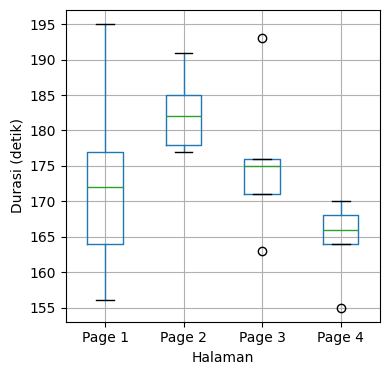

In [13]:
four_sessions = pd.read_csv(DATA + 'four_sessions.csv')
print(four_sessions.groupby('Page')['Time'].agg(['mean', 'std', 'count']).round(1))

ax = four_sessions.boxplot(by='Page', column='Time', figsize=(4, 4))
ax.set_xlabel('Halaman'); ax.set_ylabel('Durasi (detik)')
plt.suptitle(''); plt.title('')
plt.tight_layout(); plt.show()

### ANOVA dengan Permutation Test
1. Gabungkan semua data.
2. Acak, lalu bagi menjadi 4 kelompok berukuran 5.
3. Hitung **varians dari mean keempat kelompok**.
4. Ulangi langkah 2–3 berkali-kali.
5. Hitung proporsi varians hasil permutasi yang melebihi varians yang diamati → p-value.

Observed means: [172.8 182.6 175.6 164.6]
Variance      : 55.43
Pr(Prob)      : 0.08433333333333333


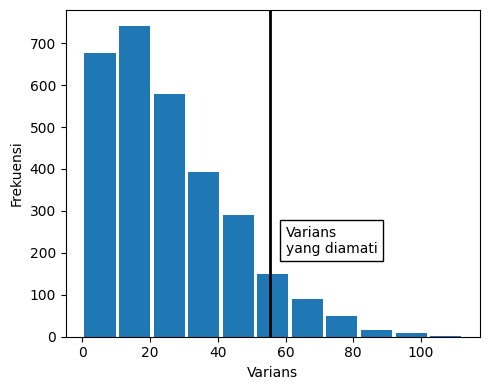

In [14]:
observed_variance = four_sessions.groupby('Page').mean().var().iloc[0]
print('Observed means:', four_sessions.groupby('Page').mean().values.ravel())
print('Variance      :', round(observed_variance, 2))

def perm_test(df):
    df = df.copy()
    df['Time'] = np.random.permutation(df['Time'].values)
    return df.groupby('Page').mean().var().iloc[0]

np.random.seed(1)
perm_variance = [perm_test(four_sessions) for _ in range(3000)]
print('Pr(Prob)      :', np.mean([var > observed_variance for var in perm_variance]))

fig, ax = plt.subplots(figsize=(5, 4))
ax.hist(perm_variance, bins=11, rwidth=0.9)
ax.axvline(x=observed_variance, color='black', lw=2)
ax.text(60, 200, 'Varians\nyang diamati', bbox={'facecolor': 'white'})
ax.set_xlabel('Varians'); ax.set_ylabel('Frekuensi')
plt.tight_layout(); plt.show()

p-value sekitar 0,08–0,09. Pada $\alpha$ = 5%, perbedaan antar keempat halaman **belum signifikan**. Kalau datanya bertambah, hasilnya bisa berubah.

### F-Statistic (ANOVA klasik)
Sama seperti t-test menggantikan permutation test untuk dua kelompok, **F-test** adalah versi klasik ANOVA. F-statistic adalah rasio:
$$F = \frac{\text{variasi antar mean kelompok (efek perlakuan)}}{\text{variasi dalam kelompok (residual error)}}$$
Semakin besar F, semakin besar kemungkinan efeknya nyata. Nilai F dibandingkan dengan **distribusi F** (Bab 2).

Tabel ANOVA memuat:
- **Df** — degrees of freedom.
- **Sum Sq** — jumlah kuadrat.
- **Mean Sq** — jumlah kuadrat dibagi df.
- **F value** dan **Pr(>F)** (p-value).

In [15]:
model = smf.ols('Time ~ Page', data=four_sessions).fit()
aov_table = sm.stats.anova_lm(model)
aov_table

,df,sum_sq,mean_sq,F,PR(>F)
Page,3.0,831.4,277.133333,2.739825,0.077586
Residual,16.0,1618.4,101.150000,NaN,NaN


In [16]:
# Alternatif: satu baris dengan scipy
res = stats.f_oneway(*[g['Time'] for _, g in four_sessions.groupby('Page')])
print(f'F = {res.statistic:.3f}, p-value = {res.pvalue:.4f}')

F = 2.740, p-value = 0.0776


F-test memberi p-value sekitar 0,078, mirip hasil permutasi.

### Decomposition of Variance
Setiap nilai observasi bisa dipecah menjadi:
**nilai = rata-rata keseluruhan + efek perlakuan (kelompok) + residual error**

ANOVA pada dasarnya membandingkan besarnya "efek perlakuan" dengan "residual error".

### Two-Way ANOVA
Jika ada **dua faktor** (misalnya halaman web × akhir pekan/hari kerja), kita memakai *two-way ANOVA*. Prinsipnya sama, tapi sekarang juga ada **efek interaksi** antara dua faktor. Two-way ANOVA adalah langkah pertama menuju model statistik penuh seperti regresi dan regresi logistik (Bab 4–5).

## 9. Chi-Square Test

Web testing sering melampaui A/B dan membandingkan banyak perlakuan sekaligus. **Chi-square test** dipakai untuk **data hitungan (count)**, untuk menguji seberapa cocok data dengan distribusi yang diharapkan.

**Istilah kunci:**
- **Chi-square statistic** — ukuran seberapa jauh data yang diamati menyimpang dari ekspektasi.
- **Expectation / expected** — hasil yang diharapkan di bawah asumsi tertentu (biasanya null hypothesis).
- **d.f.** — degrees of freedom.

Statistiknya paling sering dipakai dengan **tabel kontingensi $r \times c$** untuk menguji apakah dua variabel **independen**.

### Contoh: 3 judul (headline) web, masing-masing 1.000 pengunjung

In [17]:
click_rate = pd.read_csv(DATA + 'click_rates.csv')
clicks = click_rate.pivot(index='Click', columns='Headline', values='Rate')
clicks

Headline,Headline A,Headline B,Headline C
Click,,,
Click,14,8,12
No-click,986,992,988


Judul A tampak paling baik, tapi jumlah kliknya sangat kecil. Apakah perbedaannya nyata?

**Hipotesis nol:** ketiga judul punya tingkat klik yang sama. Tingkat klik keseluruhan = 34/3000. Maka **ekspektasi** tiap judul = 11,33 klik dan 988,67 tanpa klik.

**Pearson residual** mengukur seberapa jauh setiap sel menyimpang dari ekspektasi:
$$R = \frac{\text{Observed} - \text{Expected}}{\sqrt{\text{Expected}}}$$

**Chi-square statistic** = jumlah kuadrat semua Pearson residual:
$$X^2 = \sum_{i}^{r}\sum_{j}^{c} R^2$$

In [18]:
row_average = clicks.mean(axis=1)
expected = pd.DataFrame({
    'Headline A': row_average,
    'Headline B': row_average,
    'Headline C': row_average,
})
pearson_resid = (clicks - expected) / np.sqrt(expected)
print('Pearson residuals:\n', pearson_resid.round(3))
chi2_obs = (pearson_resid ** 2).sum().sum()
print(f'\nChi-square statistic yang diamati: {chi2_obs:.4f}')

Pearson residuals:
 Headline  Headline A  Headline B  Headline C
Click                                       
Click          0.792      -0.990       0.198
No-click      -0.085       0.106      -0.021

Chi-square statistic yang diamati: 1.6659


### Chi-square dengan Resampling
1. Buat "kotak" berisi 34 angka 1 (klik) dan 2.966 angka 0 (tanpa klik).
2. Acak, ambil 3 sampel berukuran 1.000, hitung jumlah klik tiap sampel.
3. Hitung chi-square dari hasil tersebut terhadap ekspektasi.
4. Ulangi berkali-kali; p-value = proporsi hasil yang ≥ chi-square asli.

In [19]:
box = [1] * 34
box.extend([0] * 2966)
random.shuffle(box)

def chi2(observed, expected):
    pearson_residuals = []
    for row, expect in zip(observed, expected):
        pearson_residuals.append([(observe - expect) ** 2 / expect for observe in row])
    return np.sum(pearson_residuals)

expected_clicks = 34 / 3
expected_noclicks = 1000 - expected_clicks
expected = [expected_clicks, expected_noclicks]
chi2observed = chi2(clicks.values, expected)

def perm_fun_chi(box):
    sample_clicks = [sum(random.sample(box, 1000)),
                     sum(random.sample(box, 1000)),
                     sum(random.sample(box, 1000))]
    sample_noclicks = [1000 - n for n in sample_clicks]
    return chi2([sample_clicks, sample_noclicks], expected)

random.seed(1)
perm_chi2 = [perm_fun_chi(box) for _ in range(2000)]
resampled_p_value = sum(np.array(perm_chi2) > chi2observed) / len(perm_chi2)
print(f'Observed chi2 : {chi2observed:.4f}')
print(f'Resampled p-value: {resampled_p_value:.4f}')

Observed chi2 : 1.6659
Resampled p-value: 0.4885


### Chi-square: Pendekatan Statistik (Klasik)
Teori statistik menunjukkan bahwa distribusi chi-square statistic bisa didekati dengan **distribusi chi-square** (Bab 2). Degrees of freedom untuk tabel kontingensi:

In [20]:
chisq, pvalue, df, expected = stats.chi2_contingency(clicks)
print(f'Observed chi2: {chisq:.4f}')
print(f'df           : {df}')
print(f'p-value      : {pvalue:.4f}')

Observed chi2: 1.6659
df           : 2
p-value      : 0.4348


Derajat bebas = $(r - 1) \times (c - 1) = (2-1)(3-1) = 2$.

p-value sekitar 0,43 (versi resampling ~0,49) → perbedaan tingkat klik ketiga judul **bisa jadi hanya karena kebetulan**. Tidak signifikan.

### Fisher's Exact Test
Distribusi chi-square adalah **aproksimasi** yang baik, kecuali ketika hitungannya **sangat kecil** (satu digit, terutama ≤ 5). Dalam kasus itu, lebih baik pakai prosedur resampling, atau **Fisher's exact test**, yang menghitung **semua** kemungkinan permutasi secara eksak.

Di Python, `scipy.stats.fisher_exact` tersedia untuk tabel 2×2. Untuk tabel lebih besar, pendekatan resampling seperti di atas bisa dipakai.

In [21]:
# Fisher's exact test untuk tabel 2x2 (Headline A vs Headline B)
table_ab = clicks[['Headline A', 'Headline B']].values
odds, p = stats.fisher_exact(table_ab)
print(f'Fisher exact test A vs B: p-value = {p:.4f}')

Fisher exact test A vs B: p-value = 0.2836


### Contoh dari buku: Deteksi Kecurangan Ilmiah
Buku menceritakan kasus peneliti Thereza Imanishi-Kari yang dituduh memalsukan data. Salah satu buktinya: distribusi **digit tengah** dari angka-angka dalam catatan laboratoriumnya. Digit-digit interior seharusnya terdistribusi hampir **seragam** (uniform), setiap digit 0–9 muncul dengan frekuensi yang mirip.

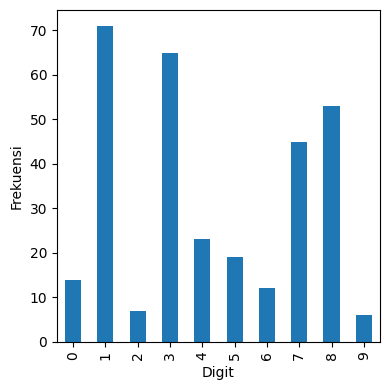

Chi-square goodness-of-fit terhadap distribusi seragam: chi2 = 174.4, p-value = 7.60e-33


In [22]:
imanishi = pd.read_csv(DATA + 'imanishi_data.csv')
imanishi.columns = [c.strip() for c in imanishi.columns]
ax = imanishi.plot.bar(x='Digit', y=['Frequency'], legend=False, figsize=(4, 4))
ax.set_xlabel('Digit'); ax.set_ylabel('Frekuensi')
plt.tight_layout(); plt.show()

chisq, p = stats.chisquare(imanishi['Frequency'])
print(f'Chi-square goodness-of-fit terhadap distribusi seragam: chi2 = {chisq:.1f}, p-value = {p:.2e}')

Distribusinya jauh dari seragam (p-value sangat kecil), yang menjadi salah satu indikasi dalam investigasi tersebut. (Catatan sejarah: dalam kasus nyata, peneliti tersebut akhirnya dinyatakan tidak bersalah oleh panel banding.)

### Relevansi untuk Data Science
- Chi-square test (atau Fisher's exact) berguna untuk mengetahui apakah sebuah efek **nyata atau kebetulan**.
- Dalam aplikasi data science klasik (A/B test web), tujuannya bukan sekadar "signifikan atau tidak", tapi **menentukan perlakuan terbaik secepat mungkin**. Untuk itu, **multi-arm bandit** sering lebih cocok.
- Chi-square juga dipakai untuk **pemilihan fitur** dalam machine learning dan untuk menentukan apakah sebuah pola (misalnya pola spasial) berbeda dari acak.

## 10. Multi-Arm Bandit

**Multi-arm bandit (MAB)** adalah pendekatan eksperimen yang memungkinkan **optimasi eksplisit** dan pengambilan keputusan **lebih cepat** daripada desain statistik tradisional.

**Istilah kunci:**
- **Multi-arm bandit** — mesin slot imajiner dengan banyak tuas, masing-masing dengan peluang menang berbeda. Analogi untuk eksperimen dengan banyak perlakuan.
- **Arm** — satu perlakuan dalam eksperimen (misalnya "judul A").
- **Win** — analogi eksperimen untuk "menang" di mesin slot (misalnya "pelanggan mengklik").

### Masalah A/B Test Tradisional
1. Hasil sering **tidak meyakinkan** ("tidak signifikan"), padahal kita tetap harus memilih.
2. Kita mungkin ingin **mulai memanfaatkan** hasil sebelum eksperimen selesai.
3. Kita ingin bisa **menyesuaikan** eksperimen dengan data baru yang masuk.

### Eksplorasi vs Eksploitasi
Pendekatan bandit menyeimbangkan dua tujuan:
- **Exploration** — terus mencoba semua opsi untuk mengumpulkan informasi.
- **Exploitation** — mengarahkan lebih banyak traffic ke opsi yang saat ini terlihat terbaik.

### Algoritma Epsilon-Greedy
1. Buat bilangan acak seragam antara 0 dan 1.
2. Jika bilangan < $\epsilon$ (angka kecil, misalnya 0,1), pilih salah satu arm **secara acak** (eksplorasi).
3. Jika tidak, tampilkan arm dengan **tingkat keberhasilan tertinggi sejauh ini** (eksploitasi).

- $\epsilon = 1$ → A/B test biasa (acak penuh).
- $\epsilon = 0$ → sepenuhnya serakah (*greedy*), tanpa eksplorasi.

### Thompson Sampling
Algoritma yang lebih canggih dan berbasis **Bayesian**: memodelkan tingkat keberhasilan tiap arm dengan distribusi **beta**. Setiap kali ada data baru, distribusinya diperbarui, dan arm dipilih berdasarkan sampel dari distribusi tersebut. Hasilnya: eksplorasi otomatis mengecil seiring bertambahnya keyakinan.

In [23]:
# Simulasi: epsilon-greedy vs Thompson sampling vs A/B (acak penuh)
true_rates = np.array([0.020, 0.025, 0.035])   # tingkat klik sebenarnya (tidak diketahui)
n_rounds = 20_000

def run_epsilon(eps, seed=0):
    rng = np.random.default_rng(seed)
    wins = np.zeros(3); pulls = np.zeros(3); total = 0
    for _ in range(n_rounds):
        if rng.random() < eps or pulls.min() == 0:
            arm = rng.integers(3)
        else:
            arm = np.argmax(wins / pulls)
        r = rng.random() < true_rates[arm]
        wins[arm] += r; pulls[arm] += 1; total += r
    return total, pulls

def run_thompson(seed=0):
    rng = np.random.default_rng(seed)
    a = np.ones(3); b = np.ones(3); total = 0; pulls = np.zeros(3)
    for _ in range(n_rounds):
        arm = np.argmax(rng.beta(a, b))
        r = rng.random() < true_rates[arm]
        a[arm] += r; b[arm] += 1 - r; pulls[arm] += 1; total += r
    return total, pulls

for name, (total, pulls) in {
    'A/B acak (eps=1)': run_epsilon(1.0),
    'Epsilon-greedy (eps=0.1)': run_epsilon(0.1),
    'Thompson sampling': run_thompson(),
}.items():
    print(f'{name:26s} total klik = {int(total):4d} | porsi traffic per arm = {(pulls / n_rounds).round(2)}')
print(f'{"Maksimum teoretis":26s} total klik ≈ {int(true_rates.max() * n_rounds)}')

A/B acak (eps=1)           total klik =  508 | porsi traffic per arm = [0.34 0.33 0.34]
Epsilon-greedy (eps=0.1)   total klik =  640 | porsi traffic per arm = [0.05 0.04 0.91]
Thompson sampling          total klik =  689 | porsi traffic per arm = [0.03 0.05 0.92]
Maksimum teoretis          total klik ≈ 700


Bandit mengarahkan sebagian besar traffic ke arm terbaik (arm ke-3) sehingga menghasilkan **lebih banyak klik total** selama eksperimen berjalan, dibanding A/B test yang membagi traffic sama rata.

## 11. Power dan Ukuran Sampel

Jika kita menjalankan web test, **berapa lama** harus dijalankan (berapa impresi per perlakuan)? Jawabannya bergantung pada seberapa besar efek yang ingin kita deteksi.

**Istilah kunci:**
- **Effect size** — besar efek minimum yang ingin dideteksi (misalnya kenaikan klik 20%).
- **Power** — probabilitas mendeteksi efek sebesar itu **jika efeknya memang ada**.
- **Significance level** — $\alpha$ yang akan dipakai.

**Power** berkaitan erat dengan **Type 2 error**: power = 1 − peluang Type 2 error.

### Menghitung Power dengan Simulasi (konsep dari buku)
1. Buat data hipotetis yang mewakili perkiraan terbaik kita (misalnya tingkat klik baseline).
2. Buat sampel kedua dengan menambahkan efek yang diinginkan (misalnya +20%).
3. Ambil sampel bootstrap berukuran $n$ dari masing-masing.
4. Jalankan uji hipotesis; catat apakah signifikan.
5. Ulangi berkali-kali. **Power = proporsi hasil yang signifikan.**

### Empat komponen yang saling terkait
Ukuran sampel, effect size, $\alpha$, dan power. Tentukan tiga, maka yang keempat bisa dihitung. Biasanya kita menetapkan effect size, $\alpha$ = 0,05, dan power = 0,8, lalu menghitung **ukuran sampel**.

### Contoh dari buku
Tingkat klik iklan saat ini sekitar **1,1%**. Kita ingin mendeteksi kenaikan **10%** (menjadi 1,21%). Berapa sampel per kelompok?

In [24]:
effect_size = sm.stats.proportion_effectsize(0.0121, 0.011)
analysis = power.TTestIndPower()
result = analysis.solve_power(effect_size=effect_size, alpha=0.05, power=0.8, alternative='larger')
print(f'Ukuran sampel per kelompok (kenaikan 10%): {result:,.0f}')

Ukuran sampel per kelompok (kenaikan 10%): 116,602


Butuh sekitar **116 ribu** impresi per iklan. Bagaimana jika efek yang ingin dideteksi lebih besar, misalnya kenaikan 50% (menjadi 1,65%)?

In [25]:
effect_size = sm.stats.proportion_effectsize(0.0165, 0.011)
result = analysis.solve_power(effect_size=effect_size, alpha=0.05, power=0.8, alternative='larger')
print(f'Ukuran sampel per kelompok (kenaikan 50%): {result:,.0f}')

Ukuran sampel per kelompok (kenaikan 50%): 5,488


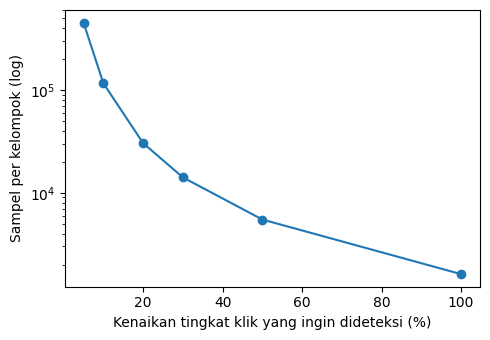

In [26]:
# Visualisasi: ukuran sampel yang dibutuhkan untuk berbagai kenaikan
lifts = np.array([0.05, 0.1, 0.2, 0.3, 0.5, 1.0])
ns = [analysis.solve_power(effect_size=sm.stats.proportion_effectsize(0.011 * (1 + l), 0.011),
                           alpha=0.05, power=0.8, alternative='larger') for l in lifts]
fig, ax = plt.subplots(figsize=(5, 3.5))
ax.plot(lifts * 100, ns, marker='o')
ax.set_yscale('log')
ax.set_xlabel('Kenaikan tingkat klik yang ingin dideteksi (%)')
ax.set_ylabel('Sampel per kelompok (log)')
plt.tight_layout(); plt.show()

In [27]:
# Power dengan simulasi (pendekatan resampling ala buku)
def sim_power(p_base, lift, n, n_sim=500, alpha=0.05, seed=0):
    rng = np.random.default_rng(seed)
    hits = 0
    for _ in range(n_sim):
        a = rng.binomial(n, p_base)
        b = rng.binomial(n, p_base * (1 + lift))
        _, p, _, _ = stats.chi2_contingency([[a, n - a], [b, n - b]])
        hits += (p / 2 < alpha) and (b > a)   # one-sided
    return hits / n_sim

print('Power (n=5.000,  kenaikan 50%):', sim_power(0.011, 0.5, 5_000))
print('Power (n=10.000, kenaikan 50%):', sim_power(0.011, 0.5, 10_000))

Power (n=5.000,  kenaikan 50%): 0.724
Power (n=10.000, kenaikan 50%): 0.948


Efek yang lebih besar butuh sampel jauh lebih kecil (sekitar 5.500 per kelompok). Simulasi memperlihatkan hal yang sama: power naik tajam ketika ukuran sampel bertambah.

**Poin kunci:**
- Menentukan ukuran sampel harus dilakukan **sebelum** eksperimen, dengan memikirkan uji statistik yang akan dipakai.
- Tentukan **effect size minimum** yang bermakna secara bisnis.
- Efek kecil butuh sampel sangat besar; kalau data tidak cukup, eksperimen mungkin tidak akan pernah memberi hasil yang meyakinkan.

## Ringkasan Bab 3

- **A/B testing** membandingkan perlakuan dengan kontrol; **randomisasi** memastikan perbedaan disebabkan oleh perlakuan, bukan faktor lain. Tentukan metrik **sebelum** eksperimen.
- **Uji hipotesis** melindungi kita dari tertipu kebetulan. $H_0$ = tidak ada efek; kita melihat seberapa ekstrem data jika $H_0$ benar.
- **Permutation test** adalah cara serbaguna dan intuitif untuk menguji hipotesis: gabungkan, acak, bagi ulang, hitung, ulangi.
- **p-value** = peluang hasil seekstrem ini jika model kebetulan benar. **Bukan** peluang hipotesis benar. Signifikan secara statistik ≠ penting secara praktis (lihat pernyataan ASA 2016).
- **Type 1 error** (false positive) dikontrol oleh $\alpha$; **Type 2 error** (false negative) berkaitan dengan power dan ukuran sampel.
- **t-test** adalah versi klasik permutation test untuk dua mean; **ANOVA/F-test** untuk banyak kelompok; **chi-square test** dan **Fisher's exact test** untuk data hitungan.
- **Multiple testing** meningkatkan peluang temuan palsu. Gunakan koreksi (Bonferroni, FDR) dan, di data science, **holdout set** serta validasi.
- **Degrees of freedom** penting untuk distribusi referensi dan untuk encoding variabel kategorikal ($k-1$ dummy).
- **Multi-arm bandit** (epsilon-greedy, Thompson sampling) menyeimbangkan eksplorasi dan eksploitasi untuk mengoptimalkan hasil **selama** eksperimen berjalan.
- **Power analysis** menentukan ukuran sampel berdasarkan effect size, $\alpha$, dan power yang diinginkan.

Pesan utama: di data science, tujuan eksperimen biasanya **membuat keputusan yang baik**, bukan sekadar membuktikan signifikansi. Resampling dan simulasi memberi cara yang intuitif dan fleksibel untuk mencapainya.